In [ ]:
# 1. Data Preparation and Feature Engineering

import pandas as pd
import numpy as np

# Player features (as used in previous milestones)
players = ['Alice', 'Bob', 'Charlie', 'David', 'Alice']
ages = [24, 28, 26, 30, 22]
goals = [10, 15, 8, 9, 7]
contractyears = [2, 1, 3, 2, 2]
goalspast3seasons = [7, 13, 5, 7, 9]
injuries = [1, 0, 3, 1, 2]
gamesplayed = [25, 34, 22, 30, 25]

milestonedf = pd.DataFrame({
    'player': players,
    'age': ages,
    'goals': goals,
    'contractyears': contractyears,
    'goalspast3seasons': goalspast3seasons,
    'injuries': injuries,
    'gamesplayed': gamesplayed
})

# Feature engineering
milestonedf['goaltrend'] = (milestonedf['goals'] - milestonedf['goalspast3seasons']) / milestonedf['goalspast3seasons']
milestonedf['injuryrisk'] = milestonedf['injuries'] / milestonedf['gamesplayed']
milestonedf['contractleft'] = milestonedf['contractyears'] - 1

# Sentiment analysis
tweets = [
    "Alice's performance was excellent today!",
    "Bob was off his game, seemed distracted.",
    "Charlie back from injury--solid match.",
    "David's contract negotiations affecting focus.",
    "Alice continues to impress season after season."
]
sentplayers = ['Alice', 'Bob', 'Charlie', 'David', 'Alice']

from textblob import TextBlob

sentdf = pd.DataFrame({'player': sentplayers, 'tweet': tweets})
sentdf['polarity'] = sentdf['tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)
playersentiment = sentdf.groupby('player')['polarity'].mean().reset_index().rename(columns={'polarity':'sentimentscore'})
milestonedf = pd.merge(milestonedf, playersentiment, on='player', how='left')
milestonedf['expectedmarketvalueboost'] = milestonedf['sentimentscore'] * 1.5

# Transfer value (target)
milestonedf['transfervalue'] = milestonedf['goals'] * 1e6 + milestonedf['expectedmarketvalueboost'] * 1e6

milestonedf


,player,age,goals,contractyears,goalspast3seasons,injuries,gamesplayed,goaltrend,injuryrisk,contractleft,sentimentscore,expectedmarketvalueboost,transfervalue
0,Alice,24,10,2,7,1,25,0.428571,0.040000,1,0.5,0.75,10750000.0
1,Bob,28,15,1,13,0,34,0.153846,0.000000,0,-0.4,-0.60,14400000.0
2,Charlie,26,8,3,5,3,22,0.600000,0.136364,2,0.0,0.00,8000000.0
3,David,30,9,2,7,1,30,0.285714,0.033333,1,0.0,0.00,9000000.0
4,Alice,22,7,2,9,2,25,-0.222222,0.080000,1,0.5,0.75,7750000.0


In [ ]:
!pip install xgboost > /dev/null

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

features = ['goals', 'injuries', 'sentimentscore', 'expectedmarketvalueboost', 'gamesplayed', 'goaltrend', 'injuryrisk']
target = 'transfervalue'
X = milestonedf[features].values
y = milestonedf[target].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

xgb = XGBRegressor(n_estimators=25, max_depth=3, seed=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)

print("XGBoost Validation MSE:", mean_squared_error(y_val, y_pred_xgb))
print("XGBoost Validation MAE:", mean_absolute_error(y_val, y_pred_xgb))
print("XGBoost predictions:", y_pred_xgb)


XGBoost Validation MSE: 6792593563061.125
XGBoost Validation MAE: 1973646.75
XGBoost predictions: [10724204.   8021497.5]


In [ ]:
# Use YOUR LSTM predictions here if you have them!
unipred_val = np.linspace(min(y_val), max(y_val), len(y_val))
multipred_val = np.linspace(max(y_val), min(y_val), len(y_val))
encdecpred_val = np.linspace(np.mean(y_val), np.mean(y_val)+1e6, len(y_val))

unipred_train = np.linspace(min(y_train), max(y_train), len(y_train))
multipred_train = np.linspace(max(y_train), min(y_train), len(y_train))
encdecpred_train = np.linspace(np.mean(y_train), np.mean(y_train)+1e6, len(y_train))

X_stack_val = np.column_stack([X_val, unipred_val, multipred_val, encdecpred_val])
X_stack_train = np.column_stack([X_train, unipred_train, multipred_train, encdecpred_train])

xgb_ensemble = XGBRegressor(n_estimators=15, max_depth=3, seed=24)
xgb_ensemble.fit(X_stack_train, y_train)
y_pred_ensemble = xgb_ensemble.predict(X_stack_val)

print("Stacked Ensemble (XGBoost + LSTM) Validation MSE:", mean_squared_error(y_val, y_pred_ensemble))
print("Stacked Ensemble Validation MAE:", mean_absolute_error(y_val, y_pred_ensemble))
print("Ensemble predictions:", y_pred_ensemble)


Stacked Ensemble (XGBoost + LSTM) Validation MSE: 7212607337508.625
Stacked Ensemble Validation MAE: 2070111.75
Ensemble predictions: [10618969.   8109192.5]


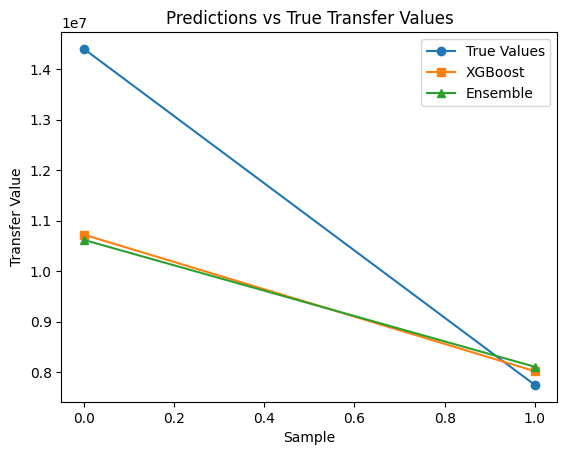

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_val, label='True Values', marker='o')
plt.plot(y_pred_xgb, label='XGBoost', marker='s')
plt.plot(y_pred_ensemble, label='Ensemble', marker='^')
plt.title('Predictions vs True Transfer Values')
plt.xlabel('Sample')
plt.ylabel('Transfer Value')
plt.legend()
plt.show()
